# Symbulator in a notebook

[Symbulator](https://symbulator.com) is a symbolic circuit solver: every answer is a SymPy expression, exact where the inputs were exact. This notebook is the package's quick start for Jupyter. The [tutorial](https://learn.symbulator.com) teaches the circuit notation; the [README](https://github.com/Symbulator/solver) documents the API.

If you are on Colab, run the next cell first.

In [1]:
# !pip install symbulator matplotlib

In [2]:
import symbulator
from symbulator import dc, ac, fd, tr, th, port, draw, polar, t, s
symbulator.__version__

'0.5.29'

## A circuit is a string

One element per line (or `:`-separated): a kind letter and a name, its two nodes, its value. Node `0` is ground. `1'k` is 1 kΩ; the apostrophe says the `k` is a prefix and not a variable.

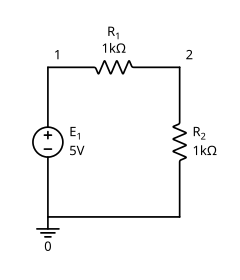

In [3]:
divider = '''
e1,1,0,5
r1,1,2,1'k
r2,2,0,1'k
'''
draw(divider)

In [4]:
res = dc(divider)
res

Result(domain='dc')
  i_e1 = -1/400
  i_r1 = 1/400
  i_r2 = 1/400
  p_e1 = -1/80
  p_r1 = 1/160
  p_r2 = 1/160
  r_e1 = 2000
  v_1 = 5
  v_2 = 5/2
  v_e1 = 5
  v_r1 = 5/2
  v_r2 = 5/2

Answers are named the way the tutorial names them: `v2` is the voltage at node 2, `ir1` the current through `r1`, `pr1` the power in it. The underscored spelling the package stores (`v_2`, `i_r1`) works too.

In [5]:
res["v2"], res["ir1"], res["pr1"]

(5/2, 1/400, 1/160)

In [6]:
res["v2"] * 2   # a SymPy expression, so arithmetic just works

5

## Symbols are fine as values

Give a component a name instead of a number and the answers come back in terms of it.

In [7]:
sym = dc("e1,1,0,vin:r1,1,2,ra:r2,2,0,rb")
sym

Result(domain='dc')
  i_e1 = -vin/(ra + rb)
  i_r1 = vin/(ra + rb)
  i_r2 = vin/(ra + rb)
  p_e1 = -vin**2/(ra + rb)
  p_r1 = ra*vin**2/(ra + rb)**2
  p_r2 = rb*vin**2/(ra + rb)**2
  r_e1 = ra + rb
  v_1 = vin
  v_2 = rb*vin/(ra + rb)
  v_e1 = vin
  v_r1 = ra*vin/(ra + rb)
  v_r2 = rb*vin/(ra + rb)

In [8]:
import sympy as sp
sp.simplify(sym["v2"])

rb*vin/(ra + rb)

## AC: phasors, and `polar()` for magnitude and angle

`ac()` needs `omega`. Complex answers print in rectangular form; `polar()` is the app's `aa` tool. `rounded()` is the app's *Rounding* setting, for display.

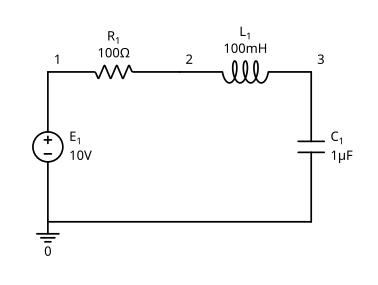

In [9]:
rlc = "e1,1,0,10:r1,1,2,100:l1,2,3,0.1:c1,3,0,1e-6"
draw(rlc)

In [10]:
ra = ac(rlc, omega=1000)
ra.rounded(4)

Result(domain='ac')
  ap_e1 = -0.006098
  ap_r1 = 0.006098
  i_c1 = 0.00122 + 0.01098*I
  i_e1 = -0.00122 - 0.01098*I
  i_l1 = 0.00122 + 0.01098*I
  i_r1 = 0.00122 + 0.01098*I
  s_c1 = -0.06098*I
  s_e1 = -0.006098 + 0.05488*I
  s_l1 = 0.006098*I
  s_r1 = 0.006098
  v_1 = 10.00
  v_2 = 9.878 - 1.098*I
  v_3 = 10.98 - 1.22*I
  v_c1 = 10.98 - 1.22*I
  v_e1 = 10.00
  v_l1 = -1.098 + 0.122*I
  v_r1 = 0.122 + 1.098*I
  z_e1 = 100.0 - 900.0*I

In [11]:
polar(ra["v2"])

9.939∠-6.340°

## Thevenin and Norton

In [12]:
th("e1,1,0,12:r1,1,2,4'k:r2,2,0,2'k", "2", "0", domain="dc")

TheveninResult(domain='dc', vth=4, ino=3/1000, req=4000/3, pmax=3/1000)

## Two-port parameters

In [13]:
port("r1,1,3,100:r2,2,3,200:r3,3,0,50", "1", "2", "z")

PortResult('z', 11=150, 12=50, 21=50, 22=250)

## Transient: the answer is a function of `t`

Use the package's own `t` when substituting or plotting -- a fresh `Symbol("t")` is a different symbol and silently matches nothing. `res.at(t=...)` substitutes by name and cannot miss.

In [14]:
rc = "e1,1,0,5:r1,1,2,1000:c1,2,0,1e-6"
rt = tr(rc, variables=["v_2"])
rt

Result(domain='tr')
  v_2 = 5.0 - 5.0*exp(-1000.0*t)

In [15]:
rt.at("v2", t=0.001)

3.16060279414279

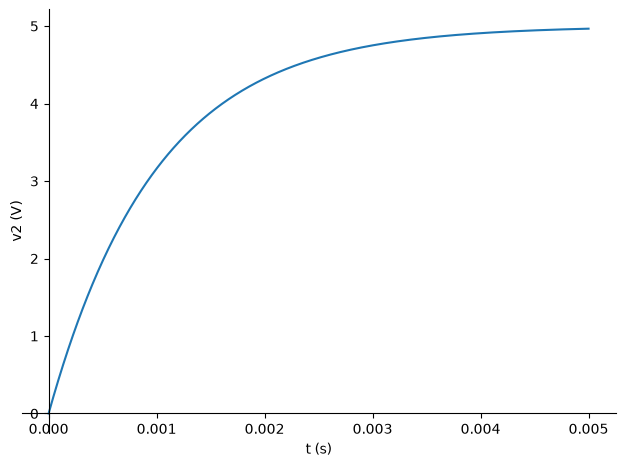

In [16]:
sp.plot(rt["v2"], (t, 0, 0.005), ylabel="v2 (V)", xlabel="t (s)");

## Frequency response

An `ac()` result is one frequency. `bode_samples()` sweeps it for you and returns arrays ready for Matplotlib.

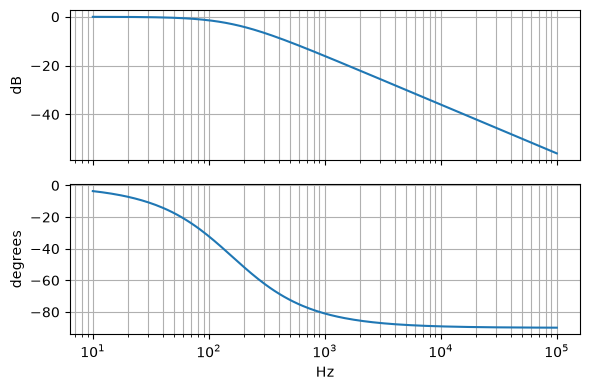

In [17]:
from symbulator import bode_samples
import matplotlib.pyplot as plt

freq, mag_db, phase = bode_samples("e1,1,0,1:r1,1,2,1000:c1,2,0,1e-6", "v_2", 10, 100_000)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6, 4))
a1.semilogx(freq, mag_db); a1.set_ylabel("dB"); a1.grid(True, which="both")
a2.semilogx(freq, phase);  a2.set_ylabel("degrees"); a2.set_xlabel("Hz"); a2.grid(True, which="both")
plt.tight_layout()

## Cell magics: a cell as a circuit

After `%load_ext symbulator`, a cell beginning `%%dc`, `%%ac`, `%%fd` or `%%tr` is a circuit: it is drawn, solved, and the answers shown. Options go on the first line -- `omega=1000`, `rms`, `variables=v_2,i_r1`, `into=res` to keep the result under a name, `nodraw`.

In [18]:
%load_ext symbulator

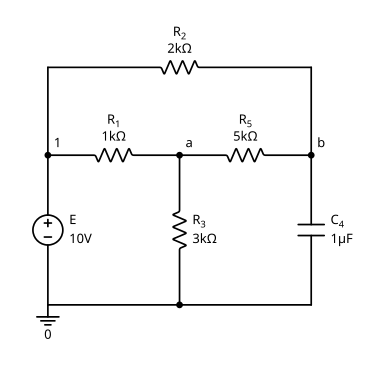

Result(domain='ac')
  ap_e = -1021/30770
  ap_r1 = 61/12308
  ap_r2 = 53/3077
  ap_r3 = 123/15385
  ap_r5 = 37/12308
  i_c4 = 667/153850 + 899*I/307700
  i_e = -1021/153850 - 841*I/307700
  i_r1 = 953/307700 + 87*I/153850
  i_r2 = 1089/307700 + 667*I/307700
  i_r3 = 177/76925 - 29*I/153850
  i_r5 = 49/61540 + 58*I/76925
  s_c4 = -841*I/61540
  s_e = -1021/30770 + 841*I/61540
  s_r1 = 61/12308
  s_r2 = 53/3077
  s_r3 = 123/15385
  s_r5 = 37/12308
  v_1 = 10
  v_a = 21240/3077 - 1740*I/3077
  v_b = 8990/3077 - 13340*I/3077
  v_c4 = 8990/3077 - 13340*I/3077
  v_e = 10
  v_r1 = 9530/3077 + 1740*I/3077
  v_r2 = 21780/3077 + 13340*I/3077
  v_r3 = 21240/3077 - 1740*I/3077
  v_r5 = 12250/3077 + 11600*I/3077
  z_e = 408400/317 - 168200*I/317

In [19]:
%%ac omega=1000 into=bridge
e,1,0,10
r1,1,a,1'k
r2,1,b,2'k
r3,a,0,3'k
c4,b,0,1'u
r5,a,b,5'k

In [20]:
polar(bridge["v_a"] - bridge["v_b"])

5.483∠43.44°

## Expert mode: your own equations

Any analysis takes `equations`, `unknowns` and `conditions`. Inside an expression, use the underscored names.

In [21]:
dc("e1,1,0,12:r1,1,2,4'k:r2,2,0,r_b", equations=["v_2 = 6"], unknowns=["r_b"])

Result(domain='dc')
  i_e1 = -3/2000
  i_r1 = 3/2000
  i_r2 = 3/2000
  p_e1 = -9/500
  p_r1 = 9/1000
  p_r2 = 9/1000
  r_b = 4000
  r_e1 = 8000
  v_1 = 12
  v_2 = 6
  v_e1 = 12
  v_r1 = 6
  v_r2 = 6

## Where next

* The tutorial, with three hundred worked problems that paste straight in: https://learn.symbulator.com
* The app, the same solver behind a form: https://symbulator.pythonanywhere.com
* The README, for the full API and the SPICE translator: https://github.com/Symbulator/solver